# Anàlisi estadística exploratòria - dataset BindCraft

Aquest notebook realitza una anàlisi estadística exploratòria sobre el dataset complet de l'article "One-shot design of functional protein binders with BindCraft", que conté dissenys contra múltiples targets (BBF-14, BetV1, CbAgo, CD45, CLDN1, DerF7, DerF21, IFNAR2, PD-L1, Sas6, SpCas9, PD1). L'objectiu és avaluar si les distribucions de les mètriques computacionals presenten diferències estadísticament significatives entre binders i non-binders, i identificar quines mètriques tenen major poder discriminatori.

In [1]:
import os
import pandas as pd
from pandas.api.types import is_numeric_dtype
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import math

df = pd.read_csv("/Users/bertaguiu/Desktop/github/bbf14/bindcraft_dataset.csv", sep=";", skiprows=2)

## Càrrega i preparació del dataframe

Es carrega el dataset de BindCraft i es realitzen les operacions de neteja inicials: eliminació de files amb valors NaN a la columna Binding, creació d'un MultiIndex Target → DesignName per facilitar les agrupacions per proteïna, conversió de totes les columnes numèriques al tipus adequat i neteja de la columna Affinity_nM (que conté asteriscs en alguns valors).

In [2]:
OUTPUT_DIR = "/Users/bertaguiu/Desktop/github/bbf14/bindcraft_dataset_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
print(df.head())

   Target DesignName                 Trajectory  Binding Affinity_nM  Length  \
0  BBF-14    BBF_b10    BBF-14_l85_s43382_mpnn1      0.0         NaN      85   
1  BBF-14    BBF_b11   BBF-14_l117_s79064_mpnn2      0.0         NaN     117   
2  BBF-14    BBF_b13  BBF-14_l102_s87116_mpnn12      0.0         NaN     102   
3  BBF-14     BBF_b5   BBF-14_l145_s38796_mpnn9      0.0         NaN     145   
4  BBF-14     BBF_b7  BBF-14_l157_s19126_mpnn17      0.0         NaN     157   

                                            Sequence  MPNN_score  \
0  MIPDDIKLTLYLINGNEVPEKVEIDPKGLSKEELKEAVKEPFEKAK...        0.74   
1  MEELKKLLEEYLKHIEWPKIVFEEIWPTLDSIEGKVKLFEWFYDNI...        1.04   
2  PARPEPEELWYKFKGKGPVVFVRVNGVLHVFKDDGNNMVSVLSAKP...        0.98   
3  LYEEFKKLYEEFLRIGMEAMIKLQEGYASGDREDEELHEEIVKLLK...        0.93   
4  SHMDYLLNWAEWQVRQLVGFLFWLFAEAGYEVIITEDTVERTETSV...        1.02   

   MPNN_seq_recovery  Average_pLDDT  ...  2_Binder_pAE  3_Binder_pAE  \
0               0.46           0.93  .

In [4]:
print(df["Binding"].value_counts())
print(len(df))

0.0    87
1.0    65
Name: Binding, dtype: int64
212


In [5]:
df = df[df["Binding"].notna()]
print(df.head())
print(len(df))

   Target DesignName                 Trajectory  Binding Affinity_nM  Length  \
0  BBF-14    BBF_b10    BBF-14_l85_s43382_mpnn1      0.0         NaN      85   
1  BBF-14    BBF_b11   BBF-14_l117_s79064_mpnn2      0.0         NaN     117   
2  BBF-14    BBF_b13  BBF-14_l102_s87116_mpnn12      0.0         NaN     102   
3  BBF-14     BBF_b5   BBF-14_l145_s38796_mpnn9      0.0         NaN     145   
4  BBF-14     BBF_b7  BBF-14_l157_s19126_mpnn17      0.0         NaN     157   

                                            Sequence  MPNN_score  \
0  MIPDDIKLTLYLINGNEVPEKVEIDPKGLSKEELKEAVKEPFEKAK...        0.74   
1  MEELKKLLEEYLKHIEWPKIVFEEIWPTLDSIEGKVKLFEWFYDNI...        1.04   
2  PARPEPEELWYKFKGKGPVVFVRVNGVLHVFKDDGNNMVSVLSAKP...        0.98   
3  LYEEFKKLYEEFLRIGMEAMIKLQEGYASGDREDEELHEEIVKLLK...        0.93   
4  SHMDYLLNWAEWQVRQLVGFLFWLFAEAGYEVIITEDTVERTETSV...        1.02   

   MPNN_seq_recovery  Average_pLDDT  ...  2_Binder_pAE  3_Binder_pAE  \
0               0.46           0.93  .

In [6]:
df = df.set_index(['Target', 'DesignName'])

In [7]:
df = df.apply(pd.to_numeric, errors="ignore")

In [8]:
numeric_like = df.columns[df.dtypes == "object"]
print(numeric_like)

Index(['Trajectory', 'Affinity_nM', 'Sequence', 'Average_InterfaceAAs',
       '1_InterfaceAAs', '2_InterfaceAAs'],
      dtype='object')


In [9]:
df["Affinity_nM"] = pd.to_numeric(
    df["Affinity_nM"].str.replace("*", "", regex=False),
    errors="coerce"
)
df["Affinity_nM"].dtype

dtype('float64')

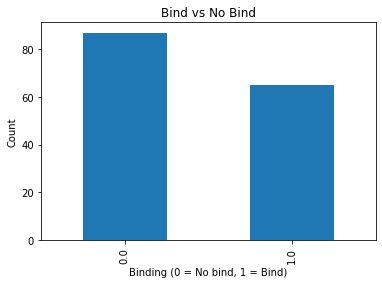

In [10]:
plt.figure()
df["Binding"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Binding (0 = No bind, 1 = Bind)")
plt.ylabel("Count")
plt.title("Bind vs No Bind")
plt.savefig(os.path.join(OUTPUT_DIR, "bind_vs_nobind_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

## Normalització Min-Max per target

Per comparar les mètriques entre targets amb escales molt diferents s'aplica una normalització Min-Max [0, 1] independent per a cada target. La funció normalize_target filtra el subset d'un target del MultiIndex i normalitza totes les columnes numèriques no binàries.

In [11]:
def normalize_target(df, target_name, level_name="Target", exclude_cols=("Binding",)):
    """
    Filtra un target d'un MultiIndex i normalitza (Min-Max 0-1)
    totes les columnes numèriques no binàries.
    
    IMPORTANT: converteix a numèric columnes que vinguin com a 'object' (strings).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame amb MultiIndex
    target_name : str
        Nom del target (ex: "BBF-14")
    level_name : str
        Nom del nivell del MultiIndex (default="Target")
    exclude_cols : tuple[str]
        Columnes a NO normalitzar (per defecte ("Binding",))
    
    Returns
    -------
    df_target_norm : pandas.DataFrame
        DataFrame filtrat i normalitzat
    """
    # 1) Filtrar target
    df_target = df.xs(target_name, level=level_name).copy()

    # 2) Intentar convertir totes les columnes (excepte exclusions) a numèric si és possible
    candidate_cols = [c for c in df_target.columns if c not in exclude_cols]

    df_num = df_target[candidate_cols].apply(pd.to_numeric, errors="coerce")

    # 3) Detectar quines columnes són realment numèriques (no tot NaN)
    numeric_cols = [c for c in df_num.columns if not df_num[c].isna().all()]

    # 4) Excloure binàries (0/1) DESPRÉS de convertir a numèric
    cols_to_scale = []
    for col in numeric_cols:
        vals = set(df_num[col].dropna().unique())
        if vals.issubset({0, 1}):
            continue
        cols_to_scale.append(col)

    # 5) Min-Max scaling per columnes
    for col in cols_to_scale:
        col_min = df_num[col].min(skipna=True)
        col_max = df_num[col].max(skipna=True)

        # Si constant o sense rang, posa 0.0 (segueix sent dins [0,1])
        if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
            df_target[col] = 0.0
        else:
            df_target[col] = (df_num[col] - col_min) / (col_max - col_min)

    return df_target

## Visualització: boxplots abans i després de la normalització

Per a cada target es generen dos boxplots: un amb els valors originals i un amb els valors normalitzats, per verificar que la normalització s'ha aplicat correctament i per observar si hi ha separació visual entre binders i non-binders en les mètriques que contenen "Average".

In [12]:
def boxplot_average_raw_vs_norm(
    df_raw_all,
    df_target_norm,
    target_name,
    level_name="Target",
    figsize=(14, 8),
    save_path=None
):
    # Filtrar el target en RAW
    df_target_raw = df_raw_all.xs(target_name, level=level_name).copy()

    # Seleccionar només columnes que contenen "Average"
    average_cols = [
        col for col in df_target_raw.columns
        if "Average" in col
    ]

    # Assegurar que són numèriques
    average_cols = [
        col for col in average_cols
        if np.issubdtype(df_target_raw[col].dtype, np.number)
    ]

    # Treure columnes constants
    average_cols = [
        col for col in average_cols
        if df_target_raw[col].max() != df_target_raw[col].min()
    ]

    # Alinear índexs
    df_target_norm = df_target_norm.reindex(df_target_raw.index)

    # Crear figura
    fig, axes = plt.subplots(2, 1, figsize=figsize, constrained_layout=True)

    # RAW
    axes[0].boxplot(
        [df_target_raw[col].dropna().values for col in average_cols],
        labels=average_cols,
        showfliers=False
    )
    axes[0].set_title(f"{target_name} — RAW (Average metrics)")
    axes[0].tick_params(axis="x", rotation=90)

    # NORMALIZED
    axes[1].boxplot(
        [df_target_norm[col].dropna().values for col in average_cols],
        labels=average_cols,
        showfliers=False
    )
    axes[1].set_title(f"{target_name} — NORMALIZED (Average metrics)")
    axes[1].tick_params(axis="x", rotation=90)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


In [13]:
def boxplot_binding_average(
    df_target,
    binding_col="Binding",
    alpha=0.05,
    top_k=20,
    showfliers=False,
    figsize=(18, 6),
    save_path=None
):
    """
    Boxplot Binders vs Non-binders per un target ja normalitzat.
    
    - Només columnes que contenen 'Average'
    - Ordenades per p-value (Mann Whitney)
    - Si hi ha significatives (p<alpha) → mostra només aquestes
    - Si n'hi ha poques → completa fins top_k amb les següents
    """

    # Columnes Average
    avg_cols = [
    c for c in df_target.columns
    if "Average" in c and np.issubdtype(df_target[c].dtype, np.number)
]

    # Separació grups
    mask_b = df_target[binding_col] == 1
    mask_nb = df_target[binding_col] == 0

    # Calcular p-values
    rows = []
    for c in avg_cols:
        xb = df_target.loc[mask_b, c].dropna().values
        xnb = df_target.loc[mask_nb, c].dropna().values

        if len(xb) < 2 or len(xnb) < 2:
            p = np.nan
        else:
            p = mannwhitneyu(xnb, xb, alternative="two-sided").pvalue

        rows.append((c, p))

    pvals = pd.DataFrame(rows, columns=["feature", "p_value"])
    pvals = pvals.sort_values("p_value", na_position="last").reset_index(drop=True)

    # Selecció features a plotejar
    plot_df = pvals.iloc[:top_k]
    plot_feats = plot_df["feature"].tolist()

    # Labels amb p-value
    def fmt(p):
        return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"

    labels = [f"{f}\n(p={fmt(p)})" for f, p in zip(plot_df["feature"], plot_df["p_value"])]

    # Preparar dades boxplot
    data_nb = [df_target.loc[mask_nb, f].dropna().values for f in plot_feats]
    data_b  = [df_target.loc[mask_b,  f].dropna().values for f in plot_feats]

    x = np.arange(len(plot_feats))
    pos_nb = x - 0.2
    pos_b  = x + 0.2

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    bp_nb = ax.boxplot(data_nb, positions=pos_nb, widths=0.35, patch_artist=True, showfliers=showfliers)
    bp_b  = ax.boxplot(data_b,  positions=pos_b,  widths=0.35, patch_artist=True, showfliers=showfliers)

    for patch in bp_nb["boxes"]:
        patch.set_facecolor("pink")
        patch.set_alpha(0.5)

    for patch in bp_b["boxes"]:
        patch.set_facecolor("green")
        patch.set_alpha(0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylabel("Value (normalized)")
    ax.set_title("Binders vs Non-binders — Average metrics")

    ax.plot([], [], color="pink", linewidth=8, alpha=0.5, label="Non-binder")
    ax.plot([], [], color="green", linewidth=8, alpha=0.5, label="Binder")
    ax.legend()

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


**BBF-14**
*Normalització + plots abans i després de normalitzar*

In [14]:
df_bbf14 = normalize_target(df, "BBF-14", level_name="Target")

Boxplot abans i després de la normalització

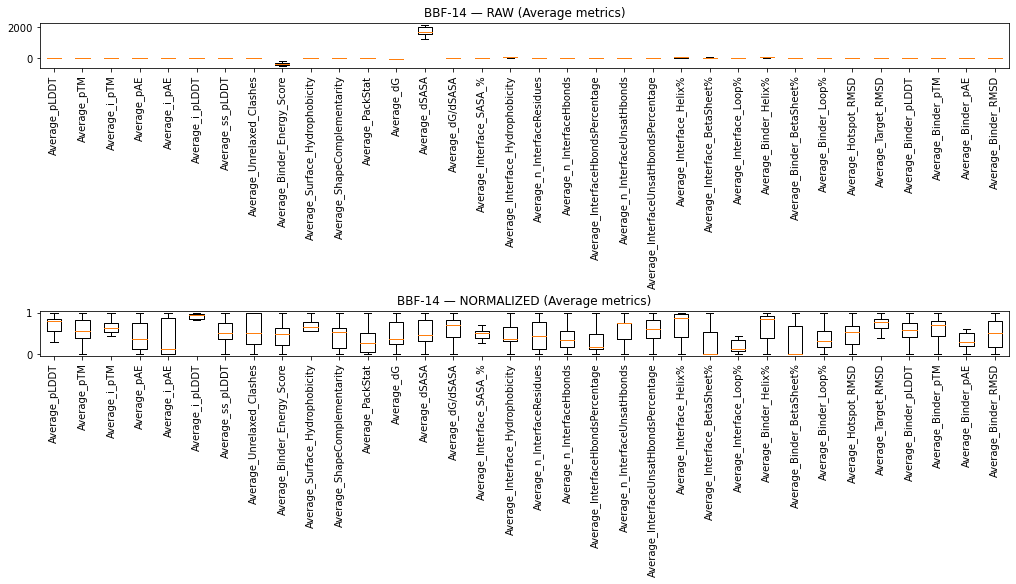

In [15]:
boxplot_average_raw_vs_norm(df, df_bbf14, "BBF-14", save_path=os.path.join(OUTPUT_DIR, "BBF_14_raw_vs_norm.png"))

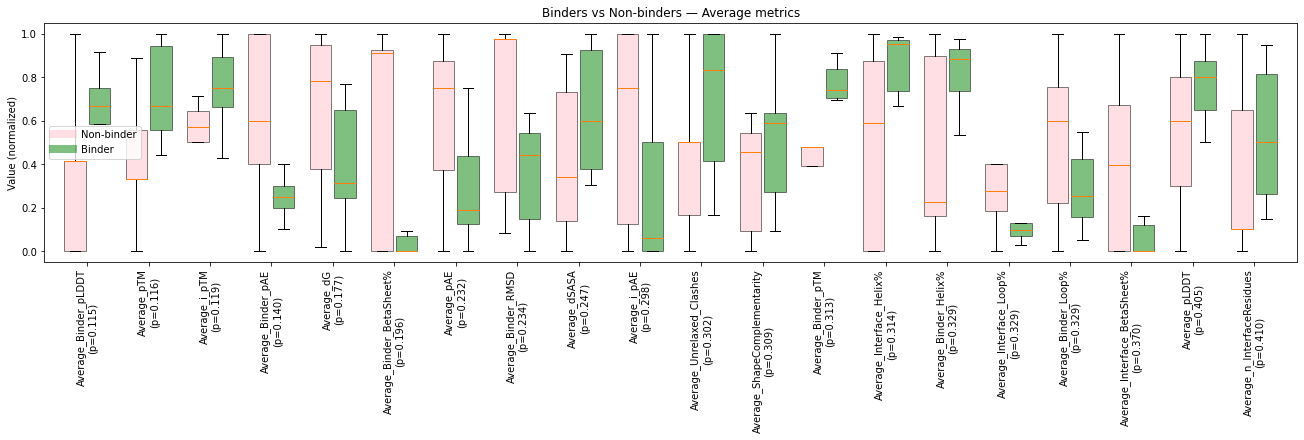

In [16]:
boxplot_binding_average(df_bbf14, save_path=os.path.join(OUTPUT_DIR, "BBF_14_binding_average.png"))

**BetV1**
*Normalització + plots abans i després de normalitzar*

In [17]:
df_betf1 = normalize_target(df, "BetV1", level_name="Target")

Boxplot abans i després de la normalització

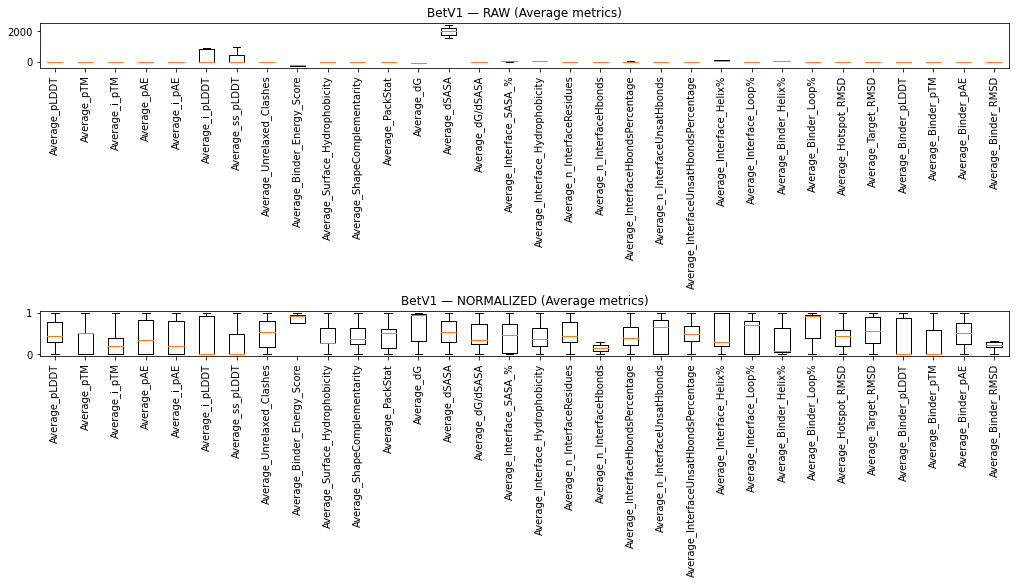

In [18]:
boxplot_average_raw_vs_norm(df, df_betf1, "BetV1", save_path=os.path.join(OUTPUT_DIR, "BetV1_raw_vs_norm.png"))

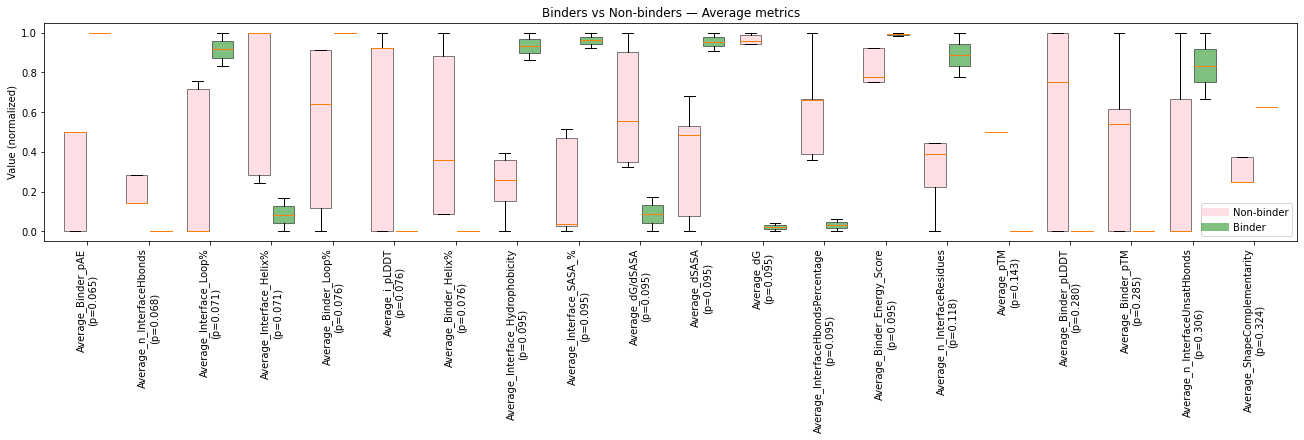

In [19]:
boxplot_binding_average(df_betf1, save_path=os.path.join(OUTPUT_DIR, "BetV1_binding_average.png"))

**CbAgo**
*Normalització + plots abans i després de normalitzar*

In [20]:
df_cbago = normalize_target(df, "CbAgo", level_name="Target")

Boxplot abans i després de la normalització

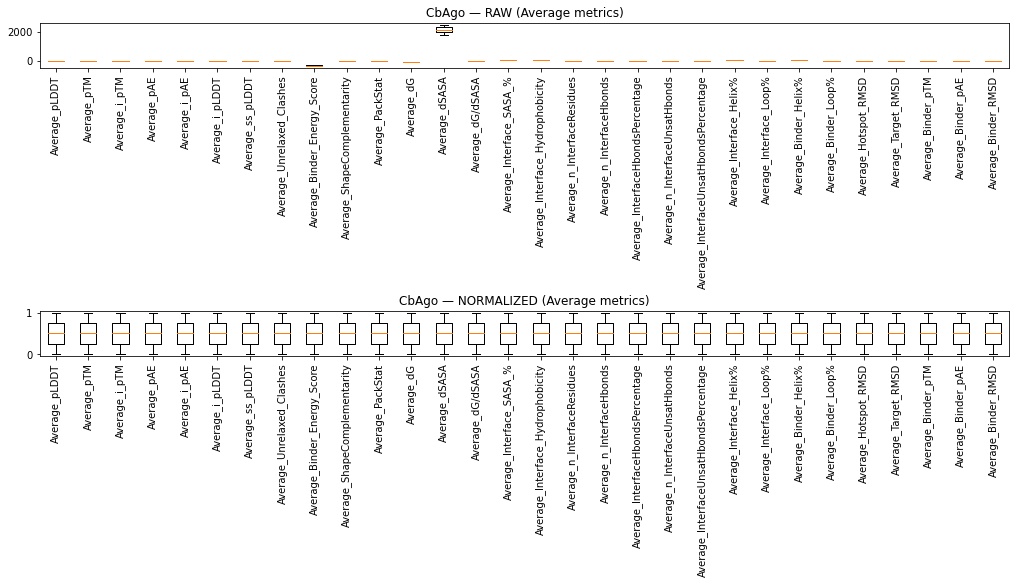

In [21]:
boxplot_average_raw_vs_norm(df, df_cbago, "CbAgo", save_path=os.path.join(OUTPUT_DIR, "CbAgo_raw_vs_norm.png"))

No hi ha cap metrica que es pugui plotejar després de filtrar.

**CD45**
*Normalització + plots abans i després de normalitzar*

In [22]:
df_cd45 = normalize_target(df, "CD45", level_name="Target")

Boxplot abans i després de la normalització

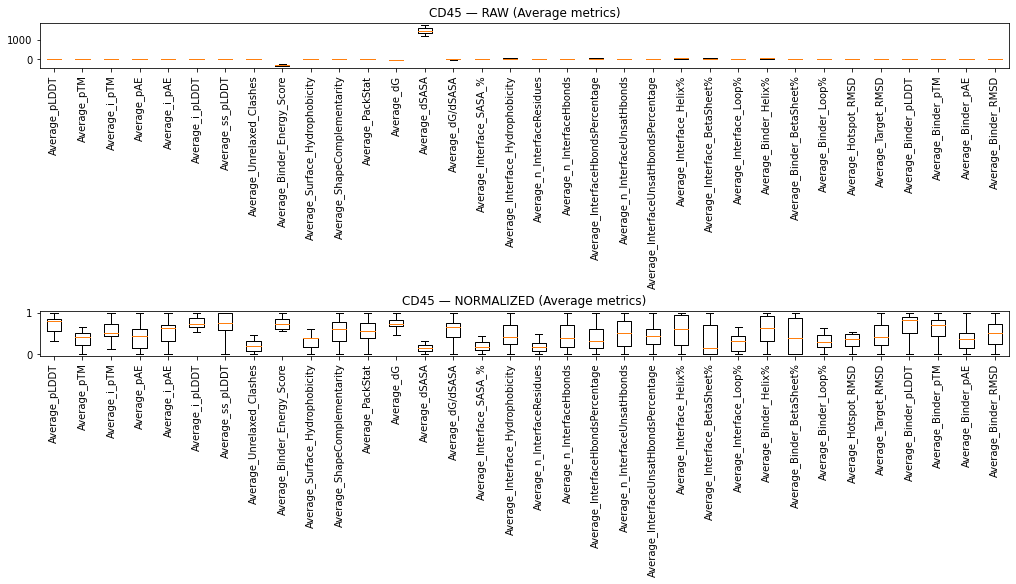

In [23]:
boxplot_average_raw_vs_norm(df, df_cd45, "CD45", save_path=os.path.join(OUTPUT_DIR, "CD45_raw_vs_norm.png"))

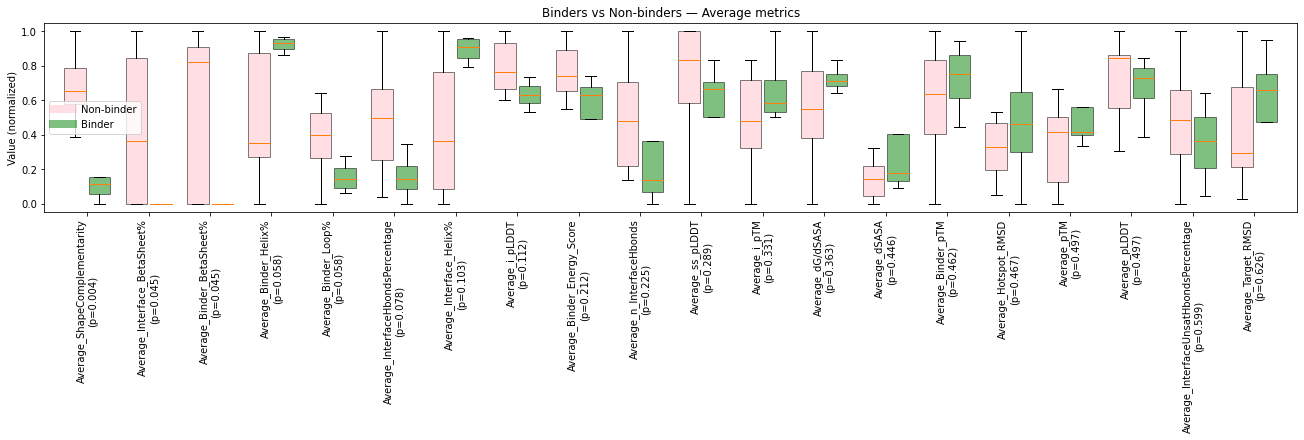

In [24]:
boxplot_binding_average(df_cd45, save_path=os.path.join(OUTPUT_DIR, "CD45_binding_average.png"))

**CLDN1**
*Normalització + plots abans i després de normalitzar*

In [25]:
df_cldn1 = normalize_target(df, "CLDN1", level_name="Target")

Boxplot abans i després de la normalització

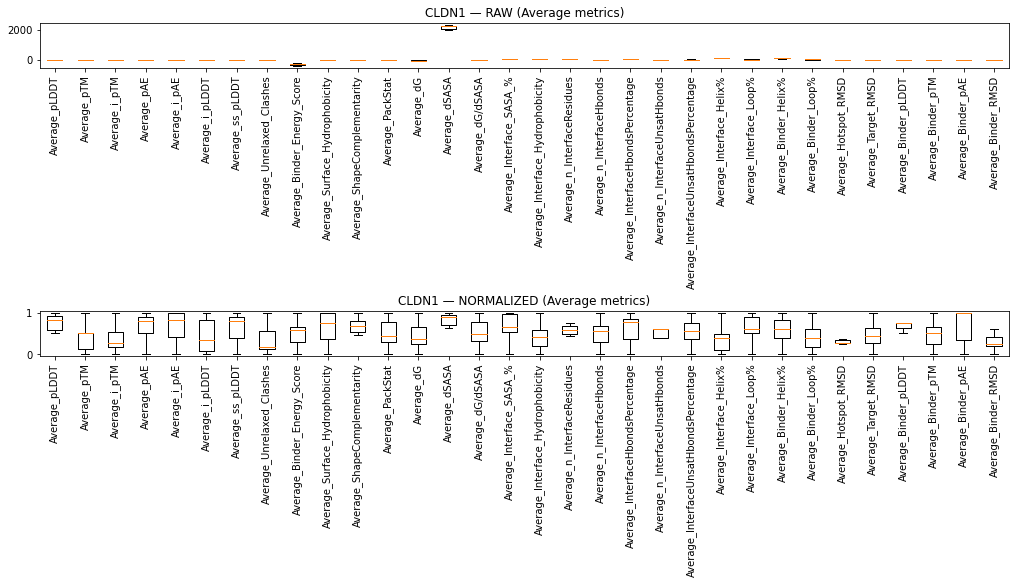

In [26]:
boxplot_average_raw_vs_norm(df, df_cldn1, "CLDN1", save_path=os.path.join(OUTPUT_DIR, "CLDN1_raw_vs_norm.png"))

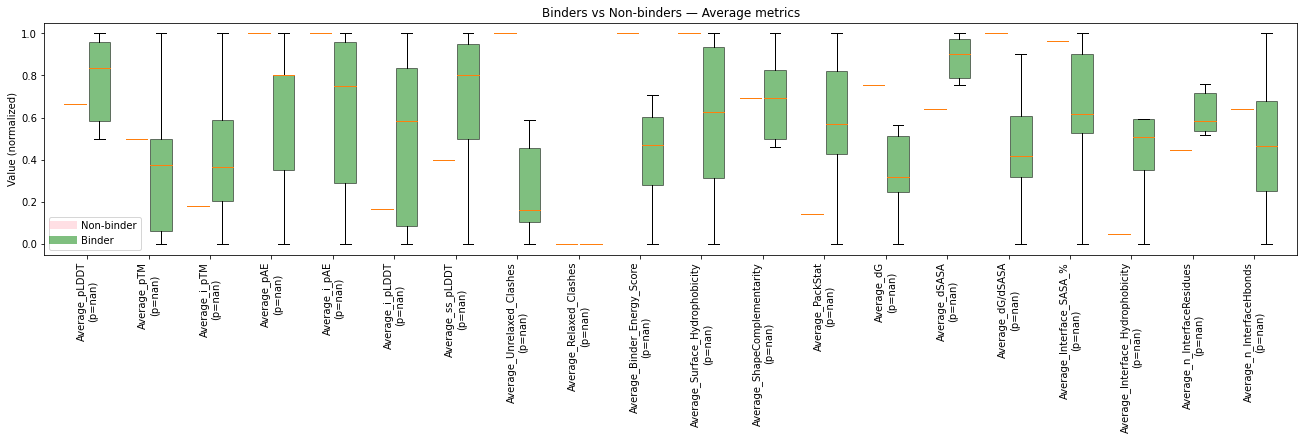

In [27]:
boxplot_binding_average(df_cldn1, save_path=os.path.join(OUTPUT_DIR, "CLDN1_binding_average.png"))

**DerF7**
*Normalització + plots abans i després de normalitzar*

In [28]:
df_derf7 = normalize_target(df, "DerF7", level_name="Target")

Boxplot abans i després de la normalització

In [29]:
boxplot_average_raw_vs_norm(df, df_derf7, "DerF7", save_path=os.path.join(OUTPUT_DIR, "DerF7_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_derf7, save_path=os.path.join(OUTPUT_DIR, "DerF7_binding_average.png"))

**DerF21**
*Normalització + plots abans i després de normalitzar*

In [105]:
df_derf21 = normalize_target(df, "DerF21", level_name="Target")

Boxplot abans i després de la normalització

In [ ]:
boxplot_average_raw_vs_norm(df, df_derf21, "DerF21", save_path=os.path.join(OUTPUT_DIR, "DerF21_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_derf21, save_path=os.path.join(OUTPUT_DIR, "DerF21_binding_average.png"))

**IFNAR2**
*Normalització + plots abans i després de normalitzar*

In [108]:
df_ifnar2 = normalize_target(df, "IFNAR2", level_name="Target")

Boxplot abans i després de la normalització

In [ ]:
boxplot_average_raw_vs_norm(df, df_ifnar2, "IFNAR2", save_path=os.path.join(OUTPUT_DIR, "IFNAR2_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_ifnar2, save_path=os.path.join(OUTPUT_DIR, "IFNAR2_binding_average.png"))

**PD-L1**
*Normalització + plots abans i després de normalitzar*

In [111]:
df_pdl1 = normalize_target(df, "PD-L1", level_name="Target")

Boxplot abans i després de la normalització

In [ ]:
boxplot_average_raw_vs_norm(df, df_pdl1, "PD-L1", save_path=os.path.join(OUTPUT_DIR, "PD_L1_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_pdl1, save_path=os.path.join(OUTPUT_DIR, "PD_L1_binding_average.png"))

**Sas6**
*Normalització + plots abans i després de normalitzar*

In [114]:
df_sas6 = normalize_target(df, "Sas6", level_name="Target")

Boxplot abans i després de la normalització

In [ ]:
boxplot_average_raw_vs_norm(df, df_sas6, "Sas6", save_path=os.path.join(OUTPUT_DIR, "Sas6_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_sas6, save_path=os.path.join(OUTPUT_DIR, "Sas6_binding_average.png"))

**SpCas9**
*Normalització + plots abans i després de normalitzar*

In [117]:
df_spcas9 = normalize_target(df, "SpCas9", level_name="Target")

Boxplot abans i després de la normalització

In [ ]:
boxplot_average_raw_vs_norm(df, df_spcas9, "SpCas9", save_path=os.path.join(OUTPUT_DIR, "SpCas9_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_spcas9, save_path=os.path.join(OUTPUT_DIR, "SpCas9_binding_average.png"))

**PD1**
*Normalització + plots abans i després de normalitzar*

In [120]:
df_pd1 = normalize_target(df, "PD1", level_name="Target")

Boxplot abans i després de la normalització

In [ ]:
boxplot_average_raw_vs_norm(df, df_pd1, "PD1", save_path=os.path.join(OUTPUT_DIR, "PD1_raw_vs_norm.png"))

In [ ]:
boxplot_binding_average(df_pd1, save_path=os.path.join(OUTPUT_DIR, "PD1_binding_average.png"))

In [123]:
targets = ["BBF-14","BetV1","CbAgo","CD45","CLDN1","DerF7","DerF21","IFNAR2","PD-L1","Sas6","SpCas9","PD1"]

df_all = pd.concat(
    [
        normalize_target(df, t, level_name="Target").assign(Target=t)
        for t in targets
    ],
    ignore_index=True,
)

## Test de Mann-Whitney per target

S'aplica el test de Mann-Whitney sobre totes les mètriques que contenen "Average" per a cada target de manera independent. Els resultats permeten identificar quines mètriques presenten diferències estadísticament significatives entre binders i non-binders per a cada proteïna, i es visualitzen en un heatmap de les top 5 i top 10 mètriques compartides entre targets.

In [124]:
def mannwhitney_all(
    df,
    target_col="Target",
    binding_col="Binding",
    alternative="two-sided",
):
    """
    Executa Mann–Whitney per cada target (agrupat per target_col)
    sobre totes les columnes que contenen 'Average'.
    """

    avg_cols = [
        c for c in df.columns
        if "Average" in c and np.issubdtype(df[c].dtype, np.number)
    ]

    results = []

    for target_name, df_target in df.groupby(target_col):

        mask_b = df_target[binding_col] == 1
        mask_nb = df_target[binding_col] == 0

        for c in avg_cols:

            xb = df_target.loc[mask_b, c].dropna().values
            xnb = df_target.loc[mask_nb, c].dropna().values

            if len(xb) < 2 or len(xnb) < 2:
                p = np.nan
            else:
                p = mannwhitneyu(xnb, xb, alternative=alternative).pvalue

            results.append((target_name, c, p))

    res = pd.DataFrame(results, columns=["target", "feature", "p_value"])
    return res

In [ ]:
res = mannwhitney_all(df_all)
res

In [ ]:
def plot_heatmap(
    res: pd.DataFrame,
    df_raw: pd.DataFrame,
    top_n_per_target: int = 10,
    top_k_shared_features: int = 5,
    score_cap: float = 8.0,
    figsize="auto",
    save_base=None,
    binding_col_raw: str = "Binding",
    target_key_raw: str = "Target",
    rotate_xticks: int = 35,
    xtick_fontsize: int = 8,
    ytick_fontsize=None,
    annot="always",
    annot_max_rows: int = 6,
    dpi_png: int = 800,
):
    # --- Validacions ---
    needed_res = {"target", "feature", "p_value"}
    missing_res = needed_res - set(res.columns)
    if missing_res:
        raise ValueError(f"Falten columnes a res: {missing_res}")
    if binding_col_raw not in df_raw.columns:
        raise ValueError(f"No trobo la columna '{binding_col_raw}' a df_raw.")

    def _get_target_series(df, key):
        if key in df.columns:
            return df[key]
        if getattr(df.index, "names", None) and key in df.index.names:
            return pd.Series(df.index.get_level_values(key), index=df.index, name=key)
        raise ValueError(f"No trobo '{key}' ni com a columna ni com a nivell del MultiIndex a df_raw.")

    raw_target = _get_target_series(df_raw, target_key_raw)
    raw_binding = df_raw[binding_col_raw]

    # --- Counts 0/1 + imbalance ---
    c0 = (raw_binding == 0).groupby(raw_target).sum()
    c1 = (raw_binding == 1).groupby(raw_target).sum()
    all_targets_raw = pd.Index(pd.unique(raw_target))

    target_counts = pd.DataFrame(index=all_targets_raw)
    target_counts["x0"] = c0.reindex(all_targets_raw, fill_value=0).astype(int)
    target_counts["y1"] = c1.reindex(all_targets_raw, fill_value=0).astype(int)
    target_counts["n"] = (target_counts["x0"] + target_counts["y1"]).astype(int)
    target_counts["imbalance"] = np.where(
        target_counts["n"] > 0,
        (target_counts["x0"] - target_counts["y1"]).abs() / target_counts["n"],
        np.nan,
    )

    # --- només p-values vàlids ---
    df = res.dropna(subset=["p_value"]).copy()
    if df.empty:
        score_df = pd.DataFrame()
        report = pd.DataFrame(columns=["feature", "n_targets_in_topN", "mean_p"])
        return score_df, report, target_counts

    targets_with_p = pd.Index(pd.unique(df["target"]))
    best_p = df.groupby("target")["p_value"].min().reindex(targets_with_p)

    # --- ordre targets: balance -> mida -> p ---
    order_df = pd.DataFrame(index=targets_with_p)
    order_df["imbalance"] = target_counts.reindex(targets_with_p)["imbalance"].fillna(1.0)
    order_df["n"] = target_counts.reindex(targets_with_p)["n"].fillna(0)
    order_df["best_p"] = best_p

    target_order = order_df.sort_values(["imbalance", "n", "best_p"], ascending=[True, False, True]).index

    # --- top-N per target ---
    df_sorted = df.sort_values(["target", "p_value"], ascending=[True, True])
    top = df_sorted.groupby("target", as_index=False).head(top_n_per_target).copy()
    top["in_top"] = True

    # --- ranking shared features ---
    top_matrix = (
        top.pivot_table(index="feature", columns="target", values="in_top", aggfunc="max", fill_value=False)
        .astype(bool)
    )
    n_targets_in_top = top_matrix.sum(axis=1).sort_values(ascending=False)
    mean_p = df.groupby("feature")["p_value"].mean()

    ranking = (
        pd.DataFrame({"n_targets_in_topN": n_targets_in_top, "mean_p": mean_p.reindex(n_targets_in_top.index)})
        .dropna()
        .sort_values(["n_targets_in_topN", "mean_p"], ascending=[False, True])
    )

    top_features = ranking.head(top_k_shared_features).index.tolist()

    # --- matriu p i score ---
    mat_p = df.pivot(index="feature", columns="target", values="p_value").reindex(top_features)
    mat_p = mat_p.reindex(columns=target_order)

    eps = np.finfo(float).tiny
    score_df = (-np.log10(np.clip(mat_p, eps, 1.0))).clip(upper=score_cap)

    # --- labels X ---
    tc_plot = target_counts.reindex(mat_p.columns).fillna(0)
    xticklabels = [f"{t}\n0:{int(tc_plot.loc[t,'x0'])} 1:{int(tc_plot.loc[t,'y1'])}" for t in mat_p.columns]

    # --- auto: annot / fonts / figsize ---
    if annot == "auto":
        do_annot = top_k_shared_features <= annot_max_rows
    else:
        do_annot = bool(annot)

    if ytick_fontsize is None:
        ytick_fontsize = 10 if top_k_shared_features <= 6 else 8 if top_k_shared_features <= 12 else 7

    if figsize == "auto":
        n_targets = len(mat_p.columns)
        width = max(8.8, 0.78 * n_targets)
        height = 2.6 + 0.18 * top_k_shared_features
        figsize = (width, height)

    linewidths = 0.35 if top_k_shared_features <= 8 else 0.25

    annot_data = None
    if do_annot:
        # Compatible amb pandas < 2.1 (applymap) i >= 2.1 (map)
        fmt_fn = lambda x: f"{x:.2g}" if pd.notna(x) else ""
        if hasattr(mat_p, "applymap"):
            annot_data = mat_p.applymap(fmt_fn)
        else:
            annot_data = mat_p.map(fmt_fn)

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=False)
    sns.heatmap(
        score_df,
        cmap="viridis",
        vmin=0,
        vmax=score_cap,
        linewidths=linewidths,
        linecolor="white",
        cbar_kws={"label": f"-log10(p) [cap {score_cap}]"},
        annot=annot_data if do_annot else False,
        fmt="",
        ax=ax,
    )

    ax.set_xticklabels(xticklabels, rotation=rotate_xticks, ha="right")
    ax.tick_params(axis="x", pad=6, labelsize=xtick_fontsize)
    ax.tick_params(axis="y", labelsize=ytick_fontsize)
    ax.set_xlabel("Target (counts 0/1)")
    ax.set_ylabel("Metric")
    ax.set_title(f"Shared top-{top_k_shared_features} metrics across targets (top-{top_n_per_target} per target)")

    fig.subplots_adjust(bottom=0.30)

    if save_base:
        fig.savefig(f"{save_base}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_base}.svg", bbox_inches="tight")
        fig.savefig(f"{save_base}.png", dpi=dpi_png, bbox_inches="tight")

    plt.show()

    report = ranking.loc[top_features].copy()
    report.insert(0, "feature", report.index)
    report = report.reset_index(drop=True)

    return score_df, report, target_counts

In [ ]:
top5, ranking10, random = plot_heatmap(res, df_raw=df, top_k_shared_features=5,
    save_base=os.path.join(OUTPUT_DIR, "heatmap_top5"))

In [ ]:
top5, ranking10, random = plot_heatmap(res, df_raw=df, top_k_shared_features=10,
    save_base=os.path.join(OUTPUT_DIR, "heatmap_top10"))

**SWARN PLOT**

In [ ]:
sns.set_theme(style="whitegrid", context="paper")

metrics = [c for c in df.columns if "Average" in c and is_numeric_dtype(df[c])]

targets = pd.Series(df.index.get_level_values("Target"), index=df.index, name="Target")
target_order = sorted(targets.dropna().unique())
palette = dict(zip(target_order, sns.color_palette("tab20", n_colors=len(target_order))))

long = df.reset_index()[["Target", "Binding"] + metrics].melt(
    id_vars=["Target", "Binding"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Value"
).dropna(subset=["Value"])

BIND_ORDER = ["Binder", "Non-binder"]
long["Binding"] = long["Binding"].astype(int).map({1: "Binder", 0: "Non-binder"})

# filtre IQR per grup; si IQR==0 (zero-inflated), retalla a Q3 (normalment 0) ---
def _iqr_filter_by_group(d, group_col="Binding", value_col="Value", k=1.5):
    parts = []
    for g, sub in d.groupby(group_col, dropna=False):
        q1 = sub[value_col].quantile(0.25)
        q3 = sub[value_col].quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr):
            parts.append(sub)
            continue

        if iqr == 0:
            # Mantén només fins a Q3 i elimina qualsevol valor per sobre
            parts.append(sub[sub[value_col] <= q3])
            continue

        lo = q1 - k * iqr
        hi = q3 + k * iqr
        parts.append(sub[(sub[value_col] >= lo) & (sub[value_col] <= hi)])

    return pd.concat(parts, axis=0)

ncols = 5                   # layout (5 per fila)
nplots = len(metrics)
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(2.6 * ncols, 2.6 * nrows),
    dpi=170
)
axes = np.array(axes).reshape(-1)

legend_handles = legend_labels = None

for i, m in enumerate(metrics):
    ax = axes[i]
    d = long[long["Metric"] == m].copy()
    d["Binding"] = pd.Categorical(d["Binding"], categories=BIND_ORDER, ordered=True)

    # treure només outliers clars (sense tocar la resta de mètriques) ---
    # ss_pLDDT i i_pLDDT (segons el teu plot) estan en escala 0-1
    if m in {"Average_ss_pLDDT", "Average_i_pLDDT"}:
        d = d[(d["Value"] >= 0) & (d["Value"] <= 1)]

    # treu el punt baix d'i_pLDDT 
    if m == "Average_i_pLDDT":
        d = _iqr_filter_by_group(d, group_col="Binding", value_col="Value", k=1.5)

    if m in {"Average_Relaxed_Clashes", "Average_Unrelaxed_Clashes"}:
        d = d[d["Value"] >= 0]
        d = _iqr_filter_by_group(d, group_col="Binding", value_col="Value", k=1.5)

    sns.violinplot(
        data=d, x="Binding", y="Value",
        order=BIND_ORDER,
        inner="quartile",
        cut=0,
        linewidth=0,
        color="0.90",
        bw_adjust=0.8,
        gridsize=200,
        ax=ax
    )

    sns.stripplot(
        data=d, x="Binding", y="Value",
        order=BIND_ORDER,
        hue="Target",
        hue_order=target_order,
        palette=palette,
        jitter=0.12,
        size=3.0,
        alpha=0.80,
        linewidth=0.2,
        edgecolor="black",
        ax=ax
    )

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_title(m, fontsize=9, pad=3)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=7)

    ax.grid(axis="y", alpha=0.20)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)

    if ax.legend_ is not None:
        ax.legend_.remove()

for j in range(nplots, len(axes)):      # eliminar subplots buits
    fig.delaxes(axes[j])

fig.subplots_adjust(hspace=0.40, wspace=0.30)

fig.legend(
    legend_handles, legend_labels,
    title="Target",
    fontsize=6,
    title_fontsize=7,
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "violin_all_metrics.png"), bbox_inches="tight", dpi=150)
plt.show()

## Correlació entre dG i dSASA

S'analitza la correlació entre les mètriques Average_dG i Average_dSASA, tant a nivell global com per target, mitjançant els coeficients de Pearson i Spearman. Aquestes dues mètriques estan relacionades conceptualment (l'energia d'interfície i la superfície accessible enterrada), i la seva correlació permet avaluar si aporten informació redundant o complementària.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

def plot_dG_dSASA_global(df, x_col="Average_dG", y_col="Average_dSASA", binding_col="Binding", save_path=None):
    """
    Plot global de x_col vs y_col per tot el dataset,
    diferenciant binders i non-binders.

    Retorna:
        results_df: DataFrame amb correlacions globals
    """

    # Si hi ha MultiIndex, el convertim a columnes per comoditat
    if isinstance(df.index, pd.MultiIndex):
        df2 = df.reset_index()
    else:
        df2 = df.copy()

    # Convertir a numèric
    df2[x_col] = pd.to_numeric(df2[x_col], errors="coerce")
    df2[y_col] = pd.to_numeric(df2[y_col], errors="coerce")
    df2[binding_col] = pd.to_numeric(df2[binding_col], errors="coerce")

    # Filtrar files útils
    df_valid = df2[[x_col, y_col, binding_col]].dropna().copy()

    if len(df_valid) < 3:
        print("No hi ha prou dades vàlides per calcular correlacions.")
        return pd.DataFrame()

    # Correlacions globals
    rho, p_spearman = spearmanr(df_valid[x_col], df_valid[y_col])
    r, p_pearson = pearsonr(df_valid[x_col], df_valid[y_col])

    # Plot
    plt.figure(figsize=(8, 6))

    for b, label in [(1, "Binder"), (0, "Non-binder")]:
        tmp = df_valid[df_valid[binding_col] == b]
        if len(tmp) > 0:
            plt.scatter(tmp[x_col], tmp[y_col], alpha=0.7, label=label)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Global dataset | Spearman rho={rho:.3f}, p={p_spearman:.3g}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

    results_df = pd.DataFrame([{
        "n": len(df_valid),
        "spearman_rho": rho,
        "spearman_p": p_spearman,
        "pearson_r": r,
        "pearson_p": p_pearson
    }])

    return results_df

In [ ]:
plot_dG_dSASA_global(df, save_path=os.path.join(OUTPUT_DIR, "scatter_dG_dSASA_global.png"))

In [ ]:
from scipy.stats import pearsonr, spearmanr

results = []

df_valid = df[df["Binding"].notna()].copy()

for target, sub in df_valid.groupby(level="Target"):
    sub = sub.copy()
    sub["Average_dG"] = pd.to_numeric(sub["Average_dG"], errors="coerce")
    sub["Average_dSASA"] = pd.to_numeric(sub["Average_dSASA"], errors="coerce")
    sub = sub[["Average_dG", "Average_dSASA"]].dropna()

    if len(sub) < 3:
        results.append({
            "Target": target,
            "n": len(sub),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan
        })
        continue

    pearson_r, pearson_p = pearsonr(sub["Average_dG"], sub["Average_dSASA"])
    spearman_rho, spearman_p = spearmanr(sub["Average_dG"], sub["Average_dSASA"])

    results.append({
        "Target": target,
        "n": len(sub),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    })

corr_by_target = pd.DataFrame(results).sort_values("spearman_p", na_position="last")
corr_by_target

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

def plot_dG_dSASA_by_target(df, x_col="Average_dG", y_col="Average_dSASA", binding_col="Binding", save_path=None):

    # Si Target és al MultiIndex
    if "Target" in df.columns:
        df2 = df.copy()
    else:
        df2 = df.reset_index()

    # convertir a numèric
    df2[x_col] = pd.to_numeric(df2[x_col], errors="coerce")
    df2[y_col] = pd.to_numeric(df2[y_col], errors="coerce")
    df2[binding_col] = pd.to_numeric(df2[binding_col], errors="coerce")

    # filtrar
    df_valid = df2[[ "Target", x_col, y_col, binding_col]].dropna()

    targets = sorted(df_valid["Target"].unique())
    n_targets = len(targets)

    if n_targets == 0:
        print("No hi ha dades vàlides")
        return

    # --- layout 3 columnes ---
    ncols = 3
    nrows = int(np.ceil(n_targets / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6*ncols, 4.5*nrows)
    )

    axes = np.array(axes).flatten()

    results = []

    for i, target in enumerate(targets):

        ax = axes[i]
        sub = df_valid[df_valid["Target"] == target]

        if len(sub) < 3:
            ax.set_title(f"{target}\nToo few points")
            ax.axis("off")
            continue

        rho, pval = spearmanr(sub[x_col], sub[y_col])
        r, p_pearson = pearsonr(sub[x_col], sub[y_col])

        for b, label in [(1,"Binder"),(0,"Non-binder")]:
            tmp = sub[sub[binding_col]==b]
            if len(tmp)>0:
                ax.scatter(tmp[x_col], tmp[y_col], alpha=0.7, label=label)

        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"{target} | ρ={rho:.3f}, p={pval:.2g}")
        ax.grid(alpha=0.3)
        ax.legend()

        results.append({
            "Target":target,
            "n":len(sub),
            "Spearman_rho":rho,
            "Spearman_p":pval,
            "Pearson_r":r,
            "Pearson_p":p_pearson
        })

    # amagar eixos buits
    for j in range(i+1,len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

    return pd.DataFrame(results)

In [ ]:
results = plot_dG_dSASA_by_target(df, save_path=os.path.join(OUTPUT_DIR, "scatter_dG_dSASA_by_target.png"))
results.to_csv(os.path.join(OUTPUT_DIR, "dG_dSASA_correlations_by_target.csv"), index=False)
display(results)